# IdiomX Dataset Analysis

This notebook presents a structured analysis of the IdiomX dataset.

We first compare the three dataset variants (Full, Balanced, High Quality),
then focus on an in-depth analysis of the Full dataset.

The goal is to provide a clear and concise understanding of:
- Data distribution
- Linguistic properties
- Dataset quality
- Text characteristics

### 1. Load Complete Dataset Versions from Hugging Face

Each IdiomX dataset version is stored with separate train and test splits.

To analyze the full dataset size for each version, we load both splits and concatenate them:

- Full dataset: `idiomx_train` + `idiomx_test`
- Balanced dataset: `idiomx_balanced_train` + `idiomx_balanced_test`
- High-quality dataset: `idiomx_high_quality_train` + `idiomx_high_quality_test`

In [1]:
# 1.1 load datasets
from datasets import load_dataset
import pandas as pd

# ---------------------------
# Full dataset
# ---------------------------
df_full_train = load_dataset("aymansharara/IdiomX", "idiomx", split="idiomx_train").to_pandas()
df_full_test = load_dataset("aymansharara/IdiomX", "idiomx", split="idiomx_test").to_pandas()
df_full = pd.concat([df_full_train, df_full_test], ignore_index=True)

# ---------------------------
# Balanced dataset
# ---------------------------
df_balanced_train = load_dataset("aymansharara/IdiomX", "idiomx_balanced", split="idiomx_balanced_train").to_pandas()
df_balanced_test = load_dataset("aymansharara/IdiomX", "idiomx_balanced", split="idiomx_balanced_test").to_pandas()
df_balanced = pd.concat([df_balanced_train, df_balanced_test], ignore_index=True)

# ---------------------------
# High-quality dataset
# ---------------------------
df_high_quality_train = load_dataset("aymansharara/IdiomX", "idiomx_high_quality", split="idiomx_high_quality_train").to_pandas()
df_high_quality_test = load_dataset("aymansharara/IdiomX", "idiomx_high_quality", split="idiomx_high_quality_test").to_pandas()
df_high_quality = pd.concat([df_high_quality_train, df_high_quality_test], ignore_index=True)

# ---------------------------
# Quick verification
# ---------------------------
print("Full dataset shape:", df_full.shape)
print("Balanced dataset shape:", df_balanced.shape)
print("High-quality dataset shape:", df_high_quality.shape)

C:\Users\ayman\Documents\IdiomX\github_idiomX\idiomx_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Full dataset shape: (174956, 52)
Balanced dataset shape: (162744, 52)
High-quality dataset shape: (123022, 52)


## 1. Dataset Overview

This section compares the three IdiomX variants at a high level before focusing on the full dataset in more detail.

In [3]:
# Dataset overview table
summary = pd.DataFrame({
    "dataset": ["Full", "Balanced", "High Quality"],
    "rows": [len(df_full), len(df_balanced), len(df_high_quality)],
    "columns": [df_full.shape[1], df_balanced.shape[1], df_high_quality.shape[1]],
    "unique_idioms": [
        df_full["idiom_canonical"].nunique(),
        df_balanced["idiom_canonical"].nunique(),
        df_high_quality["idiom_canonical"].nunique()
    ],
    "unique_examples": [
        df_full["example"].nunique(),
        df_balanced["example"].nunique(),
        df_high_quality["example"].nunique()
    ],
    "avg_examples_per_idiom": [
        round(len(df_full) / df_full["idiom_canonical"].nunique(), 2),
        round(len(df_balanced) / df_balanced["idiom_canonical"].nunique(), 2),
        round(len(df_high_quality) / df_high_quality["idiom_canonical"].nunique(), 2)
    ]
})

summary

,dataset,rows,columns,unique_idioms,unique_examples,avg_examples_per_idiom
0,Full,174956,52,12649,172481,13.83
1,Balanced,162744,52,12635,160974,12.88
2,High Quality,123022,52,12572,122065,9.79


### 1.1 Label Balance Across Dataset Variants

This figure compares the proportion of idiomatic and literal examples across the three IdiomX variants.

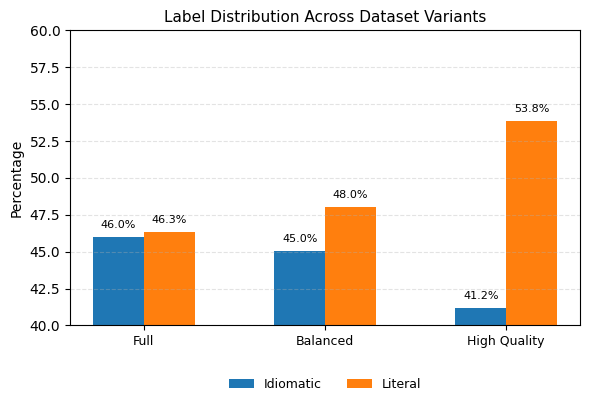

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Build label summary
def label_distribution(df, name):
    dist = df["example_usage_label"].value_counts(normalize=True) * 100
    return {
        "dataset": name,
        "idiomatic_%": round(dist.get("idiomatic", 0), 2),
        "literal_%": round(dist.get("literal", 0), 2)
    }

label_stats = pd.DataFrame([
    label_distribution(df_full, "Full"),
    label_distribution(df_balanced, "Balanced"),
    label_distribution(df_high_quality, "High Quality")
])

plot_df = label_stats.set_index("dataset")[["idiomatic_%", "literal_%"]]

fig, ax = plt.subplots(figsize=(6, 4.2))

x = np.arange(len(plot_df.index))
width = 0.28

bars1 = ax.bar(x - width/2, plot_df["idiomatic_%"], width, label="Idiomatic")
bars2 = ax.bar(x + width/2, plot_df["literal_%"], width, label="Literal")

# Value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.5,
            f"{height:.1f}%",
            ha="center",
            va="bottom",
            fontsize=8
        )

ax.set_title("Label Distribution Across Dataset Variants", fontsize=11)
ax.set_ylabel("Percentage", fontsize=10)
ax.set_xlabel("")
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, fontsize=9)
ax.set_ylim(40, 60)
ax.grid(axis="y", linestyle="--", alpha=0.35)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.14),
    ncol=2,
    frameon=False,
    fontsize=9
)

plt.tight_layout()
plt.show()

The three variants remain structurally similar, but stricter filtering shifts the data slightly toward clearer literal usage in the high-quality version.

## 2. Full Dataset Analysis

The following analysis focuses on the full IdiomX dataset, which provides the most comprehensive coverage and reflects the complete data distribution.

### 2.1 Label Distribution

The dataset maintains a balanced distribution between idiomatic and literal usage, with a smaller proportion of borderline cases.

In [5]:
label_dist_full = (
    df_full["example_usage_label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

label_dist_full

example_usage_label
literal       46.3
idiomatic     46.0
borderline     7.7
Name: proportion, dtype: float64

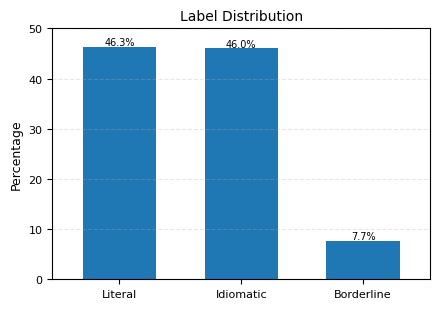

In [9]:
import matplotlib.pyplot as plt

# labels
label_dist_full.index = ["Literal", "Idiomatic", "Borderline"]

fig, ax = plt.subplots(figsize=(4.5, 3.2))

label_dist_full.plot(kind="bar", ax=ax, width=0.6)

# Value labels
for i, v in enumerate(label_dist_full.values):
    ax.text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=7)

# Titles
ax.set_title("Label Distribution", fontsize=10)
ax.set_ylabel("Percentage", fontsize=9)
ax.set_xlabel("")

# labels
ax.set_xticklabels(label_dist_full.index, rotation=0, fontsize=8)

# Y ticks
ax.tick_params(axis='y', labelsize=8)

# Tight range
ax.set_ylim(0, 50)

# grid
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

### 2.2 Compositionality

This section examines how much idiom meanings can be inferred from their individual words.

In [10]:
comp_full = (
    df_full["idiom_compositionality_level"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

comp_full

idiom_compositionality_level
semi_opaque    54.99
opaque         30.43
transparent    14.58
Name: proportion, dtype: float64

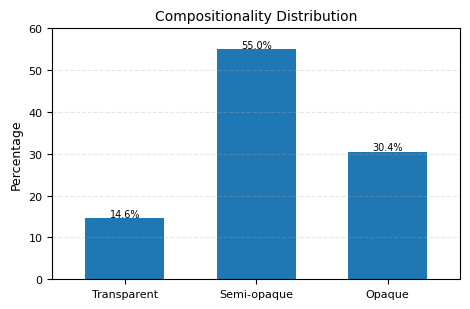

In [11]:
import matplotlib.pyplot as plt

# Optional cleaner labels and order
order = ["transparent", "semi_opaque", "opaque"]
comp_full = comp_full.reindex(order)
comp_full.index = ["Transparent", "Semi-opaque", "Opaque"]

fig, ax = plt.subplots(figsize=(4.8, 3.2))

comp_full.plot(kind="bar", ax=ax, width=0.6)

# Value labels
for i, v in enumerate(comp_full.values):
    ax.text(i, v + 0.4, f"{v:.1f}%", ha="center", fontsize=7)

ax.set_title("Compositionality Distribution", fontsize=10)
ax.set_ylabel("Percentage", fontsize=9)
ax.set_xlabel("")
ax.set_xticklabels(comp_full.index, rotation=0, fontsize=8)
ax.tick_params(axis='y', labelsize=8)
ax.set_ylim(0, 60)
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

Most idioms are semi-opaque, which means they are only partly interpretable from their words. This makes the dataset suitable for studying graded semantic understanding.

### 2.3 Learner Difficulty

This section reflects how challenging idioms are for language learners.

In [12]:
difficulty_full = (
    df_full["learner_difficulty"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

difficulty_full

learner_difficulty
medium    77.73
hard      11.90
easy      10.38
Name: proportion, dtype: float64

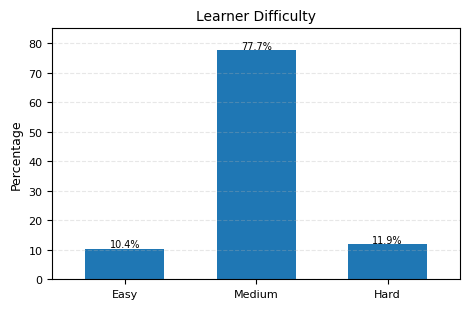

In [13]:
import matplotlib.pyplot as plt

# Order + clean labels
order = ["easy", "medium", "hard"]
difficulty_full = difficulty_full.reindex(order)
difficulty_full.index = ["Easy", "Medium", "Hard"]

fig, ax = plt.subplots(figsize=(4.8, 3.2))

difficulty_full.plot(kind="bar", ax=ax, width=0.6)

# Value labels
for i, v in enumerate(difficulty_full.values):
    ax.text(i, v + 0.4, f"{v:.1f}%", ha="center", fontsize=7)

# Titles
ax.set_title("Learner Difficulty", fontsize=10)
ax.set_ylabel("Percentage", fontsize=9)
ax.set_xlabel("")

# Clean ticks
ax.set_xticklabels(difficulty_full.index, rotation=0, fontsize=8)
ax.tick_params(axis='y', labelsize=8)

# Range
ax.set_ylim(0, 85)

# Grid
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

Most idioms fall into the medium difficulty level, reflecting the natural complexity of idiomatic language.

### 2.4 Semantic Similarity

This analysis measures how closely each example reflects the intended idiom meaning.

In [14]:
semantic_full = (
    df_full
    .groupby("example_usage_label")["semantic_similarity_example_vs_meaning"]
    .mean()
    .round(3)
)

semantic_full

example_usage_label
borderline    0.386
idiomatic     0.460
literal       0.555
Name: semantic_similarity_example_vs_meaning, dtype: float32

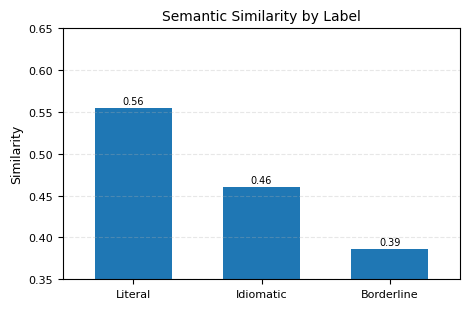

In [15]:
import matplotlib.pyplot as plt

# Order + clean labels
order = ["literal", "idiomatic", "borderline"]
semantic_full = semantic_full.reindex(order)
semantic_full.index = ["Literal", "Idiomatic", "Borderline"]

fig, ax = plt.subplots(figsize=(4.8, 3.2))

semantic_full.plot(kind="bar", ax=ax, width=0.6)

# Value labels
for i, v in enumerate(semantic_full.values):
    ax.text(i, v + 0.005, f"{v:.2f}", ha="center", fontsize=7)

# Titles
ax.set_title("Semantic Similarity by Label", fontsize=10)
ax.set_ylabel("Similarity", fontsize=9)
ax.set_xlabel("")

# Clean ticks
ax.set_xticklabels(semantic_full.index, rotation=0, fontsize=8)
ax.tick_params(axis='y', labelsize=8)

# Tight range (important)
ax.set_ylim(0.35, 0.65)

# Grid
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

Literal examples show higher similarity to the idiom meaning, while idiomatic and borderline cases are more semantically distant. This creates a meaningful gradient that supports learning fine-grained semantic distinctions.

### 2.5 Sentence Length

This section analyzes the distribution of sentence lengths in the dataset.

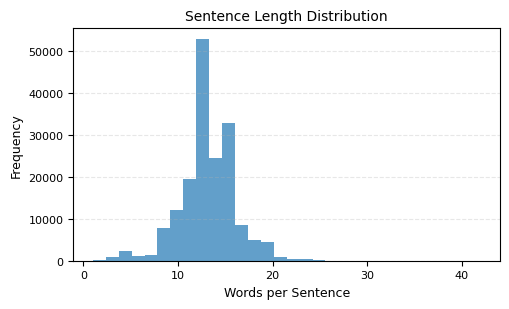

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5.2, 3.2))

ax.hist(
    df_full["sentence_length_words"],
    bins=30,
    alpha=0.7
)

# Titles
ax.set_title("Sentence Length Distribution", fontsize=10)
ax.set_xlabel("Words per Sentence", fontsize=9)
ax.set_ylabel("Frequency", fontsize=9)

# Clean ticks
ax.tick_params(axis='both', labelsize=8)

# Grid
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

Sentence lengths are moderately distributed, indicating that the dataset captures a mix of short and longer contextual expressions.

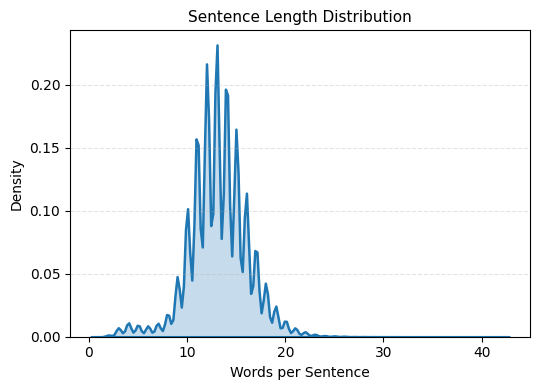

In [68]:
# Sentence Length Distribution

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(5.5, 4.0))

# KDE (smooth density)
sns.kdeplot(
    df_full["sentence_length_words"],
    fill=True,
    linewidth=1.8,
    ax=ax
)

# Titles
ax.set_title("Sentence Length Distribution", fontsize=11)
ax.set_xlabel("Words per Sentence", fontsize=10)
ax.set_ylabel("Density", fontsize=10)

# Grid
ax.grid(axis="y", linestyle="--", alpha=0.35)

plt.tight_layout()
plt.show()

### 2.6 Vocabulary Diversity

This section evaluates the lexical diversity of the dataset.

In [22]:
tokens = " ".join(df_full["example_normalized"]).split()

total_tokens = len(tokens)
unique_tokens = len(set(tokens))
ttr = unique_tokens / total_tokens

print(f"Total tokens: {total_tokens:,}")
print(f"Unique tokens: {unique_tokens:,}")
print(f"Type-Token Ratio (TTR): {ttr:.4f}")

Total tokens: 2,296,397
Unique tokens: 38,902
Type-Token Ratio (TTR): 0.0169


The dataset contains over 2.2 million tokens and nearly 39k unique words, 
reflecting rich lexical diversity. The relatively low type-token ratio is expected 
for large corpora and indicates consistent vocabulary usage across varied contexts.

### Summary of Dataset Analysis

The analysis of IdiomX highlights several key properties:

- The dataset provides large-scale coverage of idiomatic expressions with rich contextual examples.
- Label distribution is balanced, supporting robust model evaluation.
- High semantic quality is maintained, especially in the high-quality subset.
- Arabic coverage is nearly complete, enabling multilingual applications.
- The dataset is predominantly composed of general-domain idioms, reflecting natural language usage.
- Data sources are primarily dictionary-based, ensuring high reliability and consistency.

Overall, these characteristics position IdiomX as a high-quality benchmark for idiom understanding and multilingual semantic modeling.